In [1]:
import os
import json
import csv
import random
from pathlib import Path

# Data Science & Visualization
import numpy as np
import pandas as pd  # Often useful with CSVs
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Computer Vision
import cv2

# Scikit-Learn (Metrics & Preprocessing)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, auc, confusion_matrix, 
    classification_report, mean_absolute_error, 
    mean_squared_error, r2_score
)

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, Input, Model, regularizers
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Flatten, Concatenate, Layer

In [2]:
Dataset_path = "Data" 
IMG_SIZE = 224

In [ ]:
def load_dataset(root_dir="Data"):
    X_palm, X_nail, X_meta = [], [], []
    y_label, y_hb           = [], []
    subject_ids             = []

    root     = Path(root_dir)
    subjects = [p for p in root.iterdir() if p.is_dir()]

    for s in subjects:
        json_path = s / "info.json"
        if not json_path.exists():
            continue
        with open(json_path, "r") as f:
            info = json.load(f)

        age    = info["age"]
        gender = 1 if info["gender"] == "Male" else 0
        label  = 1 if info["label"] == "Anemic" else 0
        hb     = float(info["HB_Level"])

        # Palm ROI
        palm_path = s / "Palm_ROI" / "frame_03.jpg"
        if not palm_path.exists():
            continue
        palm_img = cv2.imread(str(palm_path))
        if palm_img is None:
            continue
        palm_img = cv2.cvtColor(palm_img, cv2.COLOR_BGR2RGB)
        palm_img = cv2.resize(palm_img, (IMG_SIZE, IMG_SIZE))
        palm_img = palm_img / 255.0

        # Nail ROI + background removal
        nail_path = s / "nail_roi.jpg"
        if not nail_path.exists():
            continue
        nail_img = cv2.imread(str(nail_path))
        if nail_img is None:
            continue
        nail_img = cv2.cvtColor(nail_img, cv2.COLOR_BGR2RGB)
        nail_img = cv2.resize(nail_img, (IMG_SIZE, IMG_SIZE))
        nail_img = nail_img / 255.0

        X_palm.append(palm_img)
        X_nail.append(nail_img)
        X_meta.append([age, gender])
        y_label.append(label)
        y_hb.append(hb)
        subject_ids.append(s.name)

    return (
        np.array(X_palm,       dtype=np.float32),
        np.array(X_nail,       dtype=np.float32),
        np.array(X_meta,       dtype=np.float32),
        np.array(y_label,      dtype=np.int32),
        np.array(y_hb,         dtype=np.float32),
        np.array(subject_ids))

In [5]:
X_palm, X_nail, X_meta, y_label, y_hb, subject_ids = load_dataset()

In [6]:
X_meta_raw   = X_meta.copy()

In [7]:
X_meta[:, 0] = (X_meta[:, 0] - X_meta[:, 0].mean()) / X_meta[:, 0].std()

In [8]:
print(f"Total patients : {len(subject_ids)}")
print(f"Anemic         : {sum(y_label == 1)}")
print(f"Non-Anemic     : {sum(y_label == 0)}")

# Train-Test Split
unique_subjects = np.unique(subject_ids)
unique_labels   = np.array([y_label[subject_ids == s][0] for s in unique_subjects])

train_subj, temp_subj = train_test_split(
    unique_subjects, test_size=0.30, random_state=42, stratify=unique_labels
)
temp_labels = np.array([y_label[subject_ids == s][0] for s in temp_subj])
val_subj, test_subj = train_test_split(
    temp_subj, test_size=0.50, random_state=42, stratify=temp_labels
)

train_idx = np.where(np.isin(subject_ids, train_subj))[0]
val_idx   = np.where(np.isin(subject_ids, val_subj))[0]
test_idx  = np.where(np.isin(subject_ids, test_subj))[0]

X_palm_train, X_palm_val, X_palm_test = X_palm[train_idx], X_palm[val_idx], X_palm[test_idx]
X_nail_train, X_nail_val, X_nail_test = X_nail[train_idx], X_nail[val_idx], X_nail[test_idx]
X_meta_train, X_meta_val, X_meta_test = X_meta[train_idx], X_meta[val_idx], X_meta[test_idx]

# ── Both targets ─────────────────────────────────────────────────
y_label_train, y_label_val, y_label_test = y_label[train_idx], y_label[val_idx], y_label[test_idx]
y_hb_train,    y_hb_val,    y_hb_test    = y_hb[train_idx],    y_hb[val_idx],    y_hb[test_idx]

print(f"\nTrain : {len(train_subj)} patients")
print(f"Val   : {len(val_subj)}   patients")
print(f"Test  : {len(test_subj)}  patients")

print(f"\nTrain → Anemic: {sum(y_label_train==1)}, Non-Anemic: {sum(y_label_train==0)} | HB range: {y_hb_train.min():.1f} — {y_hb_train.max():.1f}")
print(f"Val   → Anemic: {sum(y_label_val==1)},   Non-Anemic: {sum(y_label_val==0)}   | HB range: {y_hb_val.min():.1f} — {y_hb_val.max():.1f}")
print(f"Test  → Anemic: {sum(y_label_test==1)},  Non-Anemic: {sum(y_label_test==0)}  | HB range: {y_hb_test.min():.1f} — {y_hb_test.max():.1f}")

Total patients : 527
Anemic         : 264
Non-Anemic     : 263

Train : 368 patients
Val   : 79   patients
Test  : 80  patients

Train → Anemic: 184, Non-Anemic: 184 | HB range: 8.6 — 17.0
Val   → Anemic: 40,   Non-Anemic: 39   | HB range: 10.4 — 15.4
Test  → Anemic: 40,  Non-Anemic: 40  | HB range: 9.9 — 15.7


In [9]:
from Augmentation import augment_training_set, augment_training_set_joint

# joint notebook
X_palm_train, X_nail_train, X_meta_train, y_label_train, y_hb_train = augment_training_set_joint(X_palm_train, X_nail_train, X_meta_train, y_label_train, y_hb_train)

In [23]:
import importlib
import Backbones, Attention, Build

importlib.reload(Backbones)
importlib.reload(Attention)
importlib.reload(Build)

from Build import build_models

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        mode="min",
        factor=0.5,
        min_lr=1e-6
    )
]

In [12]:
model_joint_1 = build_models(backbone="cnn1", mode="joint")

In [13]:
model_joint_1.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = {
        "class_output": "binary_crossentropy",
        "reg_output":   "mse"
    },
    loss_weights = {
        "class_output": 1.0,
        "reg_output":   1.0
    },
    metrics = {
        "class_output": [tf.keras.metrics.AUC(name="auc")],
        "reg_output":   [tf.keras.metrics.MeanAbsoluteError(name="mae")]
    }
)

In [14]:
history_joint_1 = model_joint_1.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y = {
        "class_output": y_label_train,   # ← classification target
        "reg_output":   y_hb_train       # ← regression target
    },
    validation_data = (
        [X_palm_val, X_nail_val, X_meta_val],
        {
            "class_output": y_label_val,
            "reg_output":   y_hb_val
        }
    ),
    epochs     = 100,
    batch_size = 32,
    callbacks  = callbacks,
    verbose    = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - class_output_auc: 0.4687 - class_output_loss: 1.5503 - loss: 40.3132 - reg_output_loss: 38.4881 - reg_output_mae: 5.0276 - val_class_output_auc: 0.4676 - val_class_output_loss: 0.8756 - val_loss: 56.1438 - val_reg_output_loss: 52.8494 - val_reg_output_mae: 7.3264 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 553s 10s/step - class_output_auc: 0.4945 - class_output_loss: 1.1735 - loss: 10.8610 - reg_output_loss: 9.6340 - reg_output_mae: 2.4823 - val_class_output_auc: 0.4647 - val_class_output_loss: 0.8265 - val_loss: 48.9907 - val_reg_output_loss: 45.9181 - val_reg_output_mae: 6.8313 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 758s 13s/step - class_output_auc: 0.5213 - class_output_loss: 1.0213 - loss: 9.0716 - reg_output_loss: 8.0012 - reg_output_mae: 2.2509 - val_class_output_auc: 0.5327 - val_class_output_loss: 0.7540 - val_loss: 57.3059 - val_reg_output_loss: 54.2115 - val_reg_output_mae

In [15]:
def evaluate_joint_model(name, model, history):

    # ── Evaluate both outputs ────────────────────────────────────
    y_pred_class, y_pred_hb = model.predict(
        [X_palm_test, X_nail_test, X_meta_test], verbose=0
    )
    y_pred_class = y_pred_class.ravel()
    y_pred_hb    = y_pred_hb.ravel()

    # ── Youden threshold for classification ─────────────────────
    fpr, tpr, thresholds = roc_curve(y_label_test, y_pred_class)
    best_threshold       = thresholds[np.argmax(tpr - fpr)]
    y_pred_label         = (y_pred_class >= best_threshold).astype(int)

    # ── Regression metrics ───────────────────────────────────────
    r2   = r2_score(y_hb_test, y_pred_hb)
    mae  = mean_absolute_error(y_hb_test, y_pred_hb)
    rmse = np.sqrt(mean_squared_error(y_hb_test, y_pred_hb))

    # ── Print results ────────────────────────────────────────────
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")

    print(f"\n── Classification ──────────────────────────────")
    print(f"  Test AUC       : {roc_auc_score(y_label_test, y_pred_class):.4f}")
    print(f"  Best Threshold : {best_threshold:.4f}")
    print(classification_report(y_label_test, y_pred_label,
                                target_names=["Non-Anemic", "Anemic"],
                                zero_division=0))

    print(f"\n── Regression ──────────────────────────────────")
    print(f"  MAE  : {mae:.4f} g/dL")
    print(f"  RMSE : {rmse:.4f} g/dL")
    print(f"  R²   : {r2:.4f}")

    # ── Plots ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(name, fontsize=14, fontweight="bold")

    # Plot 1 - AUC curve
    axes[0].plot(history.history["val_class_output_auc"], label="val_auc")
    axes[0].plot(history.history["class_output_auc"],     label="train_auc")
    axes[0].set_title("Classification AUC")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("AUC")
    axes[0].legend()
    axes[0].grid(True)

    # Plot 2 - MAE curve
    axes[1].plot(history.history["val_reg_output_mae"], label="val_mae")
    axes[1].plot(history.history["reg_output_mae"],     label="train_mae")
    axes[1].set_title("Regression MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE (g/dL)")
    axes[1].legend()
    axes[1].grid(True)

    # Plot 3 - Loss curve
    axes[2].plot(history.history["val_loss"], label="val_loss")
    axes[2].plot(history.history["loss"],     label="train_loss")
    axes[2].set_title("Combined Loss")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].legend()
    axes[2].grid(True)

    # Plot 4 - Predicted vs Actual HB
    axes[3].scatter(y_hb_test, y_pred_hb, alpha=0.6, color="steelblue")
    axes[3].plot([y_hb_test.min(), y_hb_test.max()],
                 [y_hb_test.min(), y_hb_test.max()],
                 "r--", lw=2, label="Perfect prediction")
    axes[3].set_title(f"Predicted vs Actual HB\n(R²={r2:.3f})")
    axes[3].set_xlabel("Actual HB (g/dL)")
    axes[3].set_ylabel("Predicted HB (g/dL)")
    axes[3].legend()
    axes[3].grid(True)

    plt.tight_layout()
    plt.show()


  CNN Joint

── Classification ──────────────────────────────
  Test AUC       : 0.7031
  Best Threshold : 0.3051
              precision    recall  f1-score   support

  Non-Anemic       0.69      0.72      0.71        40
      Anemic       0.71      0.68      0.69        40

    accuracy                           0.70        80
   macro avg       0.70      0.70      0.70        80
weighted avg       0.70      0.70      0.70        80


── Regression ──────────────────────────────────
  MAE  : 0.7176 g/dL
  RMSE : 0.9037 g/dL
  R²   : 0.4616


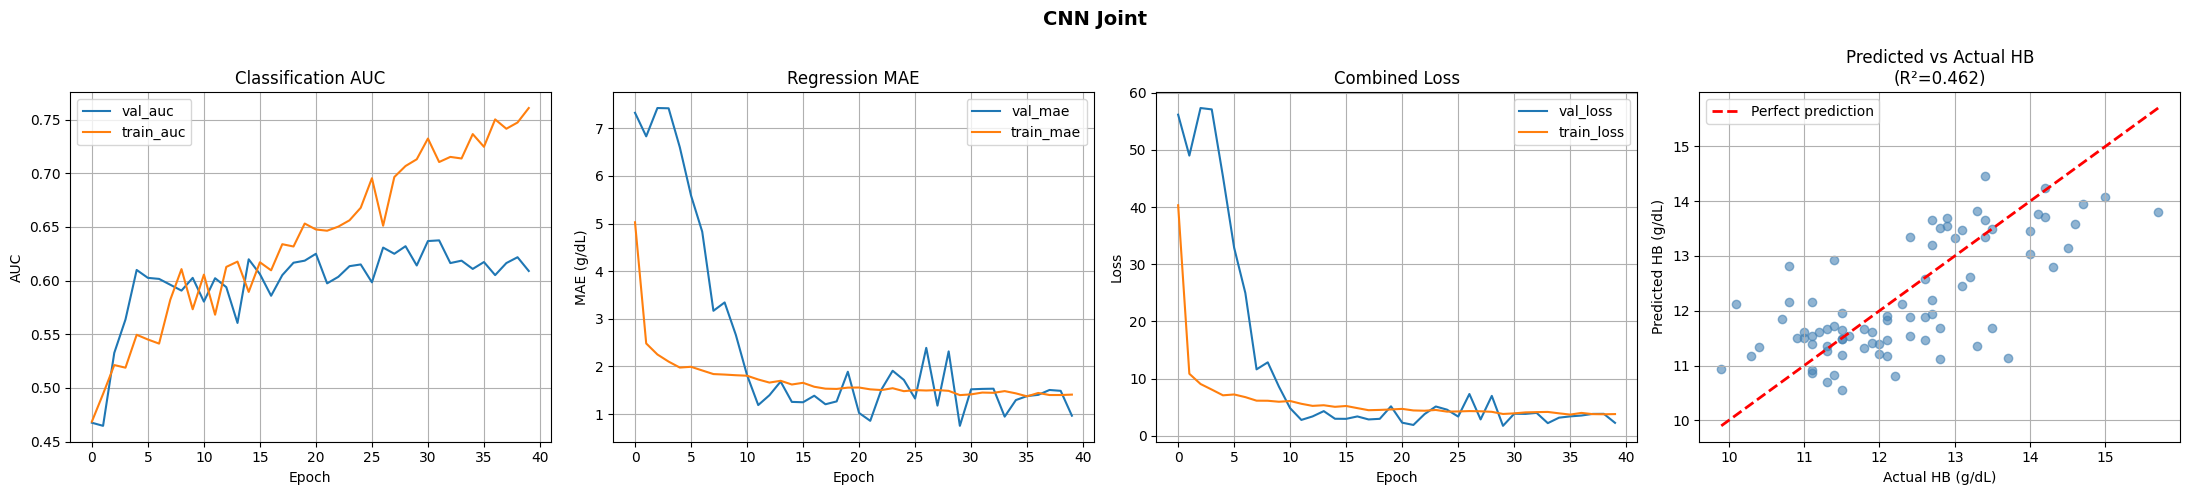

In [16]:
evaluate_joint_model("CNN Joint", model_joint_1, history_joint_1)

In [45]:
model_joint_1.save("CNN_Model.h5")

In [53]:
model_joint_1.save("CNN_Model.keras")

In [55]:
# run this in your notebook and copy the values
print(f"Age mean : {X_meta_raw[:, 0].mean()}")
print(f"Age std  : {X_meta_raw[:, 0].std()}")

Age mean : 20.227703094482422
Age std  : 2.31186842918396


In [17]:
model_joint_2 = build_models(backbone="efficientnetb0", mode="joint")

In [19]:
model_joint_2.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = {
        "class_output": "binary_crossentropy",
        "reg_output":   "mse"
    },
    loss_weights = {
        "class_output": 1.0,
        "reg_output":   1.0
    },
    metrics = {
        "class_output": [tf.keras.metrics.AUC(name="auc")],
        "reg_output":   [tf.keras.metrics.MeanAbsoluteError(name="mae")]
    }
)

In [20]:
history_joint_2 = model_joint_2.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y = {
        "class_output": y_label_train,   # ← classification target
        "reg_output":   y_hb_train       # ← regression target
    },
    validation_data = (
        [X_palm_val, X_nail_val, X_meta_val],
        {
            "class_output": y_label_val,
            "reg_output":   y_hb_val
        }
    ),
    epochs     = 100,
    batch_size = 32,
    callbacks  = callbacks,
    verbose    = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - class_output_auc: 0.4851 - class_output_loss: 1.5881 - loss: 41.7547 - reg_output_loss: 39.8216 - reg_output_mae: 5.0288 - val_class_output_auc: 0.5029 - val_class_output_loss: 0.8670 - val_loss: 3.5757 - val_reg_output_loss: 2.3150 - val_reg_output_mae: 1.2396 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - class_output_auc: 0.5046 - class_output_loss: 1.2452 - loss: 11.6855 - reg_output_loss: 10.3927 - reg_output_mae: 2.5730 - val_class_output_auc: 0.4981 - val_class_output_loss: 0.6871 - val_loss: 2.6845 - val_reg_output_loss: 1.5949 - val_reg_output_mae: 1.0340 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - class_output_auc: 0.5291 - class_output_loss: 1.1519 - loss: 9.7207 - reg_output_loss: 8.4592 - reg_output_mae: 2.3449 - val_class_output_auc: 0.5885 - val_class_output_loss: 0.6692 - val_loss: 3.0830 - val_reg_output_loss: 1.9787 - val_reg_output_mae: 1.225


  EfficientNet Joint

── Classification ──────────────────────────────
  Test AUC       : 0.6900
  Best Threshold : 0.4801
              precision    recall  f1-score   support

  Non-Anemic       0.73      0.55      0.63        40
      Anemic       0.64      0.80      0.71        40

    accuracy                           0.68        80
   macro avg       0.69      0.68      0.67        80
weighted avg       0.69      0.68      0.67        80


── Regression ──────────────────────────────────
  MAE  : 0.7636 g/dL
  RMSE : 0.9335 g/dL
  R²   : 0.4254


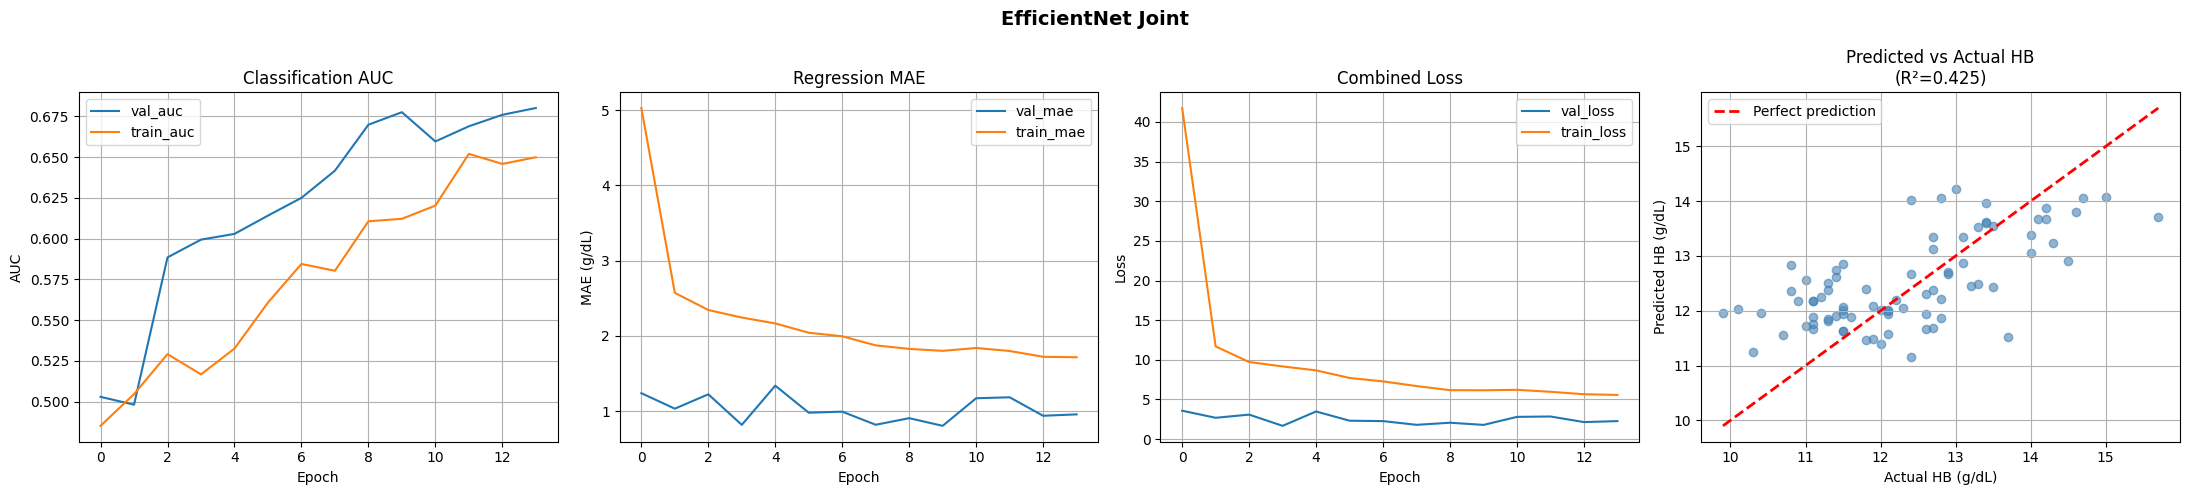

In [21]:
evaluate_joint_model("EfficientNet Joint", model_joint_2, history_joint_2)

In [31]:
model_joint_3 = build_models(backbone="densenet121", mode="joint")

In [32]:
model_joint_3.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss = {
        "class_output": "binary_crossentropy",
        "reg_output":   "mse"
    },
    loss_weights = {
        "class_output": 1.0,
        "reg_output":   1.0
    },
    metrics = {
        "class_output": [tf.keras.metrics.AUC(name="auc")],
        "reg_output":   [tf.keras.metrics.MeanAbsoluteError(name="mae")]
    }
)

In [33]:
history_joint_3 = model_joint_3.fit(
    x = [X_palm_train, X_nail_train, X_meta_train],
    y = {
        "class_output": y_label_train,   # ← classification target
        "reg_output":   y_hb_train       # ← regression target
    },
    validation_data = (
        [X_palm_val, X_nail_val, X_meta_val],
        {
            "class_output": y_label_val,
            "reg_output":   y_hb_val
        }
    ),
    epochs     = 100,
    batch_size = 32,
    callbacks  = callbacks,
    verbose    = 1
)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 393s 5s/step - class_output_auc: 0.4778 - class_output_loss: 1.2068 - loss: 34.4476 - reg_output_loss: 32.9663 - reg_output_mae: 4.5365 - val_class_output_auc: 0.4381 - val_class_output_loss: 0.9550 - val_loss: 10.8549 - val_reg_output_loss: 9.1727 - val_reg_output_mae: 2.9247 - learning_rate: 1.0000e-04
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 252s 4s/step - class_output_auc: 0.4938 - class_output_loss: 1.1177 - loss: 9.7876 - reg_output_loss: 8.5930 - reg_output_mae: 2.3632 - val_class_output_auc: 0.4455 - val_class_output_loss: 0.8598 - val_loss: 2.7316 - val_reg_output_loss: 1.6158 - val_reg_output_mae: 1.1086 - learning_rate: 1.0000e-04
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - class_output_auc: 0.5182 - class_output_loss: 1.0481 - loss: 8.1183 - reg_output_loss: 6.9937 - reg_output_mae: 2.1124 - val_class_output_auc: 0.4686 - val_class_output_loss: 0.7671 - val_loss: 2.0049 - val_reg_output_loss: 1.0577 - val_reg_output_mae: 0.8863


  DenseNet Joint

── Classification ──────────────────────────────
  Test AUC       : 0.4450
  Best Threshold : 0.2260
              precision    recall  f1-score   support

  Non-Anemic       0.52      0.28      0.36        40
      Anemic       0.51      0.75      0.61        40

    accuracy                           0.51        80
   macro avg       0.52      0.51      0.48        80
weighted avg       0.52      0.51      0.48        80


── Regression ──────────────────────────────────
  MAE  : 3.0266 g/dL
  RMSE : 3.2536 g/dL
  R²   : -5.9797


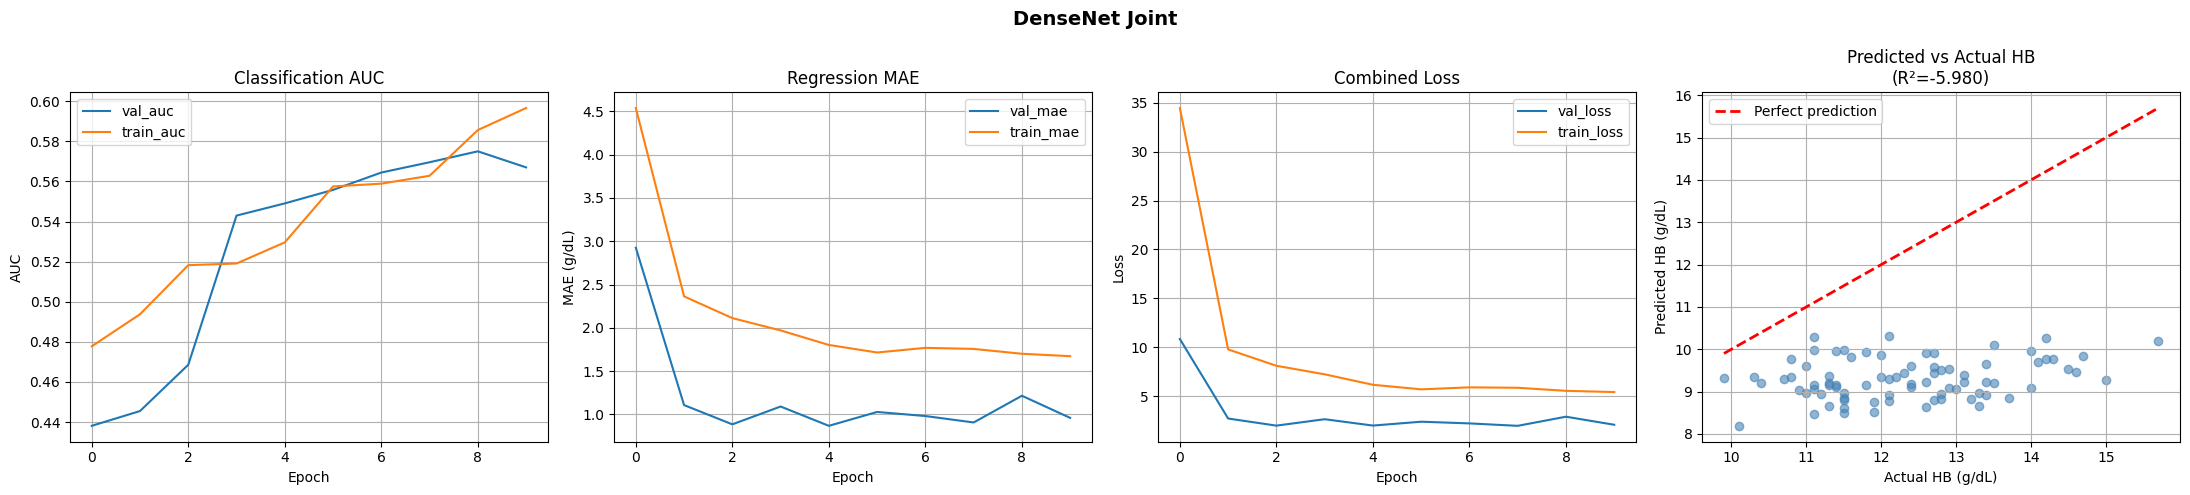

In [35]:
evaluate_joint_model("DenseNet Joint", model_joint_3, history_joint_3)

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

N_SPLITS            = 5
skf                 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
train_subject_ids   = subject_ids[train_idx]
unique_train_subj   = np.unique(train_subject_ids)
unique_train_labels = np.array([y_label[train_idx][train_subject_ids == s][0]
                                 for s in unique_train_subj])
fold_results = []

In [39]:
for fold, (tr_subj_idx, vl_subj_idx) in enumerate(
    skf.split(unique_train_subj, unique_train_labels)
):
    
    print(f"FOLD {fold+1}/{N_SPLITS}")

    tr_subj = unique_train_subj[tr_subj_idx]
    vl_subj = unique_train_subj[vl_subj_idx]
    tr_idx  = np.where(np.isin(train_subject_ids, tr_subj))[0]
    vl_idx  = np.where(np.isin(train_subject_ids, vl_subj))[0]

    X_palm_tr = X_palm_train[tr_idx];  X_palm_vl = X_palm_train[vl_idx]
    X_nail_tr = X_nail_train[tr_idx];  X_nail_vl = X_nail_train[vl_idx]
    X_meta_tr = X_meta_train[tr_idx];  X_meta_vl = X_meta_train[vl_idx]
    y_lbl_tr  = y_label_train[tr_idx]; y_lbl_vl  = y_label_train[vl_idx]
    y_hb_tr   = y_hb_train[tr_idx];    y_hb_vl   = y_hb_train[vl_idx]

    # ── Augment ──────────────────────────────────────────────────
    X_palm_tr, X_nail_tr, X_meta_tr, y_lbl_tr, y_hb_tr = augment_training_set_joint(
        X_palm_tr, X_nail_tr, X_meta_tr, y_lbl_tr, y_hb_tr
    )
    print(f"Train size : {len(y_lbl_tr)} | Val size: {len(y_lbl_vl)}")

    # ── Model ────────────────────────────────────────────────────
    model_joint_1K = build_models(backbone="cnn1", mode="joint")
    model_joint_1K.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss = {
            "class_output": "binary_crossentropy",
            "reg_output":   "mse"
        },
        loss_weights = {
            "class_output": 1.0,
            "reg_output":   1.0
        },
        metrics = {
            "class_output": [tf.keras.metrics.AUC(name="auc")],
            "reg_output":   [tf.keras.metrics.MeanAbsoluteError(name="mae")]
        }
    )

    fold_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10,
            mode="min", restore_best_weights=True, verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", patience=5,
            mode="min", factor=0.5, min_lr=1e-6, verbose=0
        )
    ]

    model_joint_1K.fit(
        x = [X_palm_tr, X_nail_tr, X_meta_tr],
        y = {
            "class_output": y_lbl_tr,
            "reg_output":   y_hb_tr
        },
        validation_data = (
            [X_palm_vl, X_nail_vl, X_meta_vl],
            {
                "class_output": y_lbl_vl,
                "reg_output":   y_hb_vl
            }
        ),
        epochs=100, batch_size=32,
        callbacks=fold_callbacks, verbose=1
    )

    # ── Evaluate fold ────────────────────────────────────────────
    y_pred_class, y_pred_hb = model_joint_1K.predict(
        [X_palm_vl, X_nail_vl, X_meta_vl], verbose=0
    )
    y_pred_class = y_pred_class.ravel()
    y_pred_hb    = y_pred_hb.ravel()

    # classification
    fpr, tpr, thresholds = roc_curve(y_lbl_vl, y_pred_class)
    best_t    = thresholds[np.argmax(tpr - fpr)]
    auc_score = roc_auc_score(y_lbl_vl, y_pred_class)

    # regression
    mae  = mean_absolute_error(y_hb_vl, y_pred_hb)
    rmse = np.sqrt(mean_squared_error(y_hb_vl, y_pred_hb))
    r2   = r2_score(y_hb_vl, y_pred_hb)

    print(f"\nFold {fold+1} → AUC: {auc_score:.4f} | Threshold: {best_t:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

    fold_results.append({
        "fold"     : fold + 1,
        "auc"      : auc_score,
        "threshold": best_t,
        "mae"      : mae,
        "rmse"     : rmse,
        "r2"       : r2,
        "model"    : model_joint_1K
    })

FOLD 1/5
Train size : 1470 | Val size: 74
Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - class_output_auc: 0.4618 - class_output_loss: 1.0677 - loss: 46.4696 - reg_output_loss: 45.2900 - reg_output_mae: 5.4858 - val_class_output_auc: 0.6495 - val_class_output_loss: 0.6999 - val_loss: 55.2943 - val_reg_output_loss: 55.0956 - val_reg_output_mae: 7.2580 - learning_rate: 1.0000e-04
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 125s 3s/step - class_output_auc: 0.5267 - class_output_loss: 1.0141 - loss: 9.6531 - reg_output_loss: 8.5751 - reg_output_mae: 2.3426 - val_class_output_auc: 0.7365 - val_class_output_loss: 0.7203 - val_loss: 62.8345 - val_reg_output_loss: 62.3623 - val_reg_output_mae: 7.7721 - learning_rate: 1.0000e-04
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - class_output_auc: 0.4800 - class_output_loss: 1.0794 - loss: 8.8912 - reg_output_loss: 7.7525 - reg_output_mae: 2.2179 - val_class_output_auc: 0.7240 - val_class_output_loss: 0.7268 - val_loss: 82.4199 - val_reg_ou

In [40]:
print("K-FOLD SUMMARY — CNN1 Joint")

aucs  = [r["auc"]  for r in fold_results]
maes  = [r["mae"]  for r in fold_results]
r2s   = [r["r2"]   for r in fold_results]

for r in fold_results:
    print(f"Fold {r['fold']} → AUC: {r['auc']:.4f} | MAE: {r['mae']:.4f} | R²: {r['r2']:.4f}")

print(f"\nMean AUC : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"Mean MAE : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"Mean R²  : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")

K-FOLD SUMMARY — CNN1 Joint
Fold 1 → AUC: 0.7639 | MAE: 0.8141 | R²: 0.5708
Fold 2 → AUC: 0.7846 | MAE: 1.1020 | R²: 0.1801
Fold 3 → AUC: 0.7104 | MAE: 0.7309 | R²: 0.4688
Fold 4 → AUC: 0.7881 | MAE: 0.6688 | R²: 0.5490
Fold 5 → AUC: 0.6833 | MAE: 0.7179 | R²: 0.5070

Mean AUC : 0.7461 ± 0.0419
Mean MAE : 0.8068 ± 0.1549
Mean R²  : 0.4552 ± 0.1419


In [41]:
best_fold  = fold_results[np.argmax(aucs)]
best_model = best_fold["model"]
print(f"\n✅ Best Fold: {best_fold['fold']} (AUC={best_fold['auc']:.4f} | MAE={best_fold['mae']:.4f})")


✅ Best Fold: 4 (AUC=0.7881 | MAE=0.6688)


In [48]:
y_pred_class_test, y_pred_hb_test = best_model.predict(
    [X_palm_test, X_nail_test, X_meta_test], verbose=0
)
y_pred_class_test = y_pred_class_test.ravel()
y_pred_hb_test    = y_pred_hb_test.ravel()

fpr, tpr, thresholds = roc_curve(y_label_test, y_pred_class_test)
best_threshold = thresholds[np.argmax(tpr - fpr)]
y_pred_label   = (y_pred_class_test >= best_threshold).astype(int)


In [49]:
print("FINAL TEST RESULTS — CNN1 Joint")

print(f"\n── Classification ──────────────────────────────")
print(f"  AUC       : {roc_auc_score(y_label_test, y_pred_class_test):.4f}")
print(f"  Threshold : {best_threshold:.4f}")
print(classification_report(y_label_test, y_pred_label,
                            target_names=["Non-Anemic", "Anemic"], zero_division=0))

print(f"\n── Regression ──────────────────────────────────")
print(f"  MAE  : {mean_absolute_error(y_hb_test, y_pred_hb_test):.4f} g/dL")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_hb_test, y_pred_hb_test)):.4f} g/dL")
print(f"  R²   : {r2_score(y_hb_test, y_pred_hb_test):.4f}")

FINAL TEST RESULTS — CNN1 Joint

── Classification ──────────────────────────────
  AUC       : 0.6831
  Threshold : 0.4016
              precision    recall  f1-score   support

  Non-Anemic       0.78      0.53      0.63        40
      Anemic       0.64      0.85      0.73        40

    accuracy                           0.69        80
   macro avg       0.71      0.69      0.68        80
weighted avg       0.71      0.69      0.68        80


── Regression ──────────────────────────────────
  MAE  : 0.7950 g/dL
  RMSE : 0.9926 g/dL
  R²   : 0.3504


In [ ]:
for fold, (tr_subj_idx, vl_subj_idx) in enumerate(
    skf.split(unique_train_subj, unique_train_labels)
):
    
    print(f"FOLD {fold+1}/{N_SPLITS}")

    tr_subj = unique_train_subj[tr_subj_idx]
    vl_subj = unique_train_subj[vl_subj_idx]
    tr_idx  = np.where(np.isin(train_subject_ids, tr_subj))[0]
    vl_idx  = np.where(np.isin(train_subject_ids, vl_subj))[0]

    X_palm_tr = X_palm_train[tr_idx];  X_palm_vl = X_palm_train[vl_idx]
    X_nail_tr = X_nail_train[tr_idx];  X_nail_vl = X_nail_train[vl_idx]
    X_meta_tr = X_meta_train[tr_idx];  X_meta_vl = X_meta_train[vl_idx]
    y_lbl_tr  = y_label_train[tr_idx]; y_lbl_vl  = y_label_train[vl_idx]
    y_hb_tr   = y_hb_train[tr_idx];    y_hb_vl   = y_hb_train[vl_idx]

    # ── Augment ──────────────────────────────────────────────────
    X_palm_tr, X_nail_tr, X_meta_tr, y_lbl_tr, y_hb_tr = augment_training_set_joint(
        X_palm_tr, X_nail_tr, X_meta_tr, y_lbl_tr, y_hb_tr
    )
    print(f"Train size : {len(y_lbl_tr)} | Val size: {len(y_lbl_vl)}")

    # ── Model ────────────────────────────────────────────────────
    model_joint_1K = build_models(backbone="cnn1", mode="joint")
    model_joint_1K.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss = {
            "class_output": "binary_crossentropy",
            "reg_output":   "mse"
        },
        loss_weights = {
            "class_output": 1.0,
            "reg_output":   1.0
        },
        metrics = {
            "class_output": [tf.keras.metrics.AUC(name="auc")],
            "reg_output":   [tf.keras.metrics.MeanAbsoluteError(name="mae")]
        }
    )

    fold_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10,
            mode="min", restore_best_weights=True, verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", patience=5,
            mode="min", factor=0.5, min_lr=1e-6, verbose=0
        )
    ]

    model_joint_1K.fit(
        x = [X_palm_tr, X_nail_tr, X_meta_tr],
        y = {
            "class_output": y_lbl_tr,
            "reg_output":   y_hb_tr
        },
        validation_data = (
            [X_palm_vl, X_nail_vl, X_meta_vl],
            {
                "class_output": y_lbl_vl,
                "reg_output":   y_hb_vl
            }
        ),
        epochs=100, batch_size=32,
        callbacks=fold_callbacks, verbose=1
    )

    # ── Evaluate fold ────────────────────────────────────────────
    y_pred_class, y_pred_hb = model_joint_1K.predict(
        [X_palm_vl, X_nail_vl, X_meta_vl], verbose=0
    )
    y_pred_class = y_pred_class.ravel()
    y_pred_hb    = y_pred_hb.ravel()

    # classification
    fpr, tpr, thresholds = roc_curve(y_lbl_vl, y_pred_class)
    best_t    = thresholds[np.argmax(tpr - fpr)]
    auc_score = roc_auc_score(y_lbl_vl, y_pred_class)

    # regression
    mae  = mean_absolute_error(y_hb_vl, y_pred_hb)
    rmse = np.sqrt(mean_squared_error(y_hb_vl, y_pred_hb))
    r2   = r2_score(y_hb_vl, y_pred_hb)

    print(f"\nFold {fold+1} → AUC: {auc_score:.4f} | Threshold: {best_t:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

    fold_results.append({
        "fold"     : fold + 1,
        "auc"      : auc_score,
        "threshold": best_t,
        "mae"      : mae,
        "rmse"     : rmse,
        "r2"       : r2,
        "model"    : model_joint_1K
    })

In [51]:
N_SPLITS            = 5
skf                 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
X_palm_all  = X_palm
X_nail_all  = X_nail
X_meta_all  = X_meta
y_label_all = y_label
y_hb_all    = y_hb

fold_results = []

In [52]:


# ── Use ALL data (train + val + test) for k-fold ─────────────────


for fold, (tr_idx, te_idx) in enumerate(
    skf.split(X_palm_all, y_label_all)
):
   
    print(f"FOLD {fold+1}/{N_SPLITS}")
    

    X_palm_tr = X_palm_all[tr_idx];  X_palm_te = X_palm_all[te_idx]
    X_nail_tr = X_nail_all[tr_idx];  X_nail_te = X_nail_all[te_idx]
    X_meta_tr = X_meta_all[tr_idx];  X_meta_te = X_meta_all[te_idx]
    y_lbl_tr  = y_label_all[tr_idx]; y_lbl_te  = y_label_all[te_idx]
    y_hb_tr   = y_hb_all[tr_idx];    y_hb_te   = y_hb_all[te_idx]

    # ── Augment training fold only ───────────────────────────────
    X_palm_tr, X_nail_tr, X_meta_tr, y_lbl_tr, y_hb_tr = augment_training_set_joint(
        X_palm_tr, X_nail_tr, X_meta_tr, y_lbl_tr, y_hb_tr
    )
    print(f"Train size : {len(y_lbl_tr)} | Test size: {len(y_lbl_te)}")

    # ── Model ────────────────────────────────────────────────────
    model = build_models(backbone="cnn1", mode="joint")
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss = {
            "class_output": "binary_crossentropy",
            "reg_output":   "mse"
        },
        loss_weights = {
            "class_output": 1.0,
            "reg_output":   1.0
        },
        metrics = {
            "class_output": [tf.keras.metrics.AUC(name="auc")],
            "reg_output":   [tf.keras.metrics.MeanAbsoluteError(name="mae")]
        }
    )

    fold_callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10,
            mode="min", restore_best_weights=True, verbose=0
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", patience=5,
            mode="min", factor=0.5, min_lr=1e-6, verbose=0
        )
    ]

    model.fit(
        x = [X_palm_tr, X_nail_tr, X_meta_tr],
        y = {
            "class_output": y_lbl_tr,
            "reg_output":   y_hb_tr
        },
        validation_data = (
            [X_palm_te, X_nail_te, X_meta_te],
            {
                "class_output": y_lbl_te,
                "reg_output":   y_hb_te
            }
        ),
        epochs=100, batch_size=32,
        callbacks=fold_callbacks, verbose=1
    )

    # ── Evaluate on test fold ────────────────────────────────────
    y_pred_class, y_pred_hb = model.predict(
        [X_palm_te, X_nail_te, X_meta_te], verbose=0
    )
    y_pred_class = y_pred_class.ravel()
    y_pred_hb    = y_pred_hb.ravel()

    fpr, tpr, thresholds = roc_curve(y_lbl_te, y_pred_class)
    best_t    = thresholds[np.argmax(tpr - fpr)]
    auc_score = roc_auc_score(y_lbl_te, y_pred_class)
    mae       = mean_absolute_error(y_hb_te, y_pred_hb)
    rmse      = np.sqrt(mean_squared_error(y_hb_te, y_pred_hb))
    r2        = r2_score(y_hb_te, y_pred_hb)

    print(f"\nFold {fold+1} → AUC: {auc_score:.4f} | Threshold: {best_t:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

    fold_results.append({
        "fold"     : fold + 1,
        "auc"      : auc_score,
        "threshold": best_t,
        "mae"      : mae,
        "rmse"     : rmse,
        "r2"       : r2,
        "model"    : model
    })



FOLD 1/5


MemoryError: Unable to allocate 1.18 GiB for an array with shape (2105, 224, 224, 3) and data type float32

In [ ]:
# ── Summary ──────────────────────────────────────────────────────
aucs  = [r["auc"]  for r in fold_results]
maes  = [r["mae"]  for r in fold_results]
r2s   = [r["r2"]   for r in fold_results]
rmses = [r["rmse"] for r in fold_results]

print(f"\n{'='*50}")
print("K-FOLD SUMMARY — CNN1 Joint")
print(f"{'='*50}")
for r in fold_results:
    print(f"Fold {r['fold']} → AUC: {r['auc']:.4f} | Threshold: {r['threshold']:.4f} | MAE: {r['mae']:.4f} | R²: {r['r2']:.4f}")

print(f"\nMean AUC  : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"Mean MAE  : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"Mean RMSE : {np.mean(rmses):.4f} ± {np.std(rmses):.4f}")
print(f"Mean R²   : {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")